# Getting the data ready

In [2]:
import pandas as pd

features = pd.read_csv('/content/features.csv')
sales = pd.read_csv('/content/sales.csv')
stores = pd.read_csv('/content/stores.csv')

In [3]:
features.head()

,store_id,date,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday,holiday_name,season
0,1,2022-01-01,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2022-01-08,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,0,NaN,Winter
2,1,2022-01-15,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,0,NaN,Winter
3,1,2022-01-22,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,0,NaN,Winter
4,1,2022-01-29,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,0,NaN,Winter


In [4]:
sales.head()


,store_id,department,date,weekly_sales,is_holiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1
3,1,4,2022-01-01,88445.24,1
4,1,5,2022-01-01,65159.85,1


In [5]:
stores.head()

,store_id,store_type,store_size,region
0,1,A,213810,North
1,2,C,31639,East
2,3,B,102098,South
3,4,B,88289,North
4,5,A,218696,North


In [6]:
features.drop('is_holiday', axis = 1, inplace = True)

In [7]:
df = sales.merge(features, on = ['store_id', 'date'], how = 'left')
df = df.merge(stores, on = 'store_id', how = 'left')

df.dtypes

,0
store_id,int64
department,int64
date,object
weekly_sales,float64
is_holiday,int64
temperature,float64
fuel_price,float64
markdown_1,float64
markdown_2,float64
markdown_3,float64


In [8]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear
df['quarter'] = df['date'].dt.quarter

df = df.sort_values(['store_id', 'department', 'date'])

df['weekly_sales'] = np.log1p(df['weekly_sales']) # minimize ejections
df['lag_1'] = df.groupby(['store_id', 'department'])['weekly_sales'].shift(1)
df['lag_4'] = df.groupby(['store_id', 'department'])['weekly_sales'].shift(4)
df['lag_52'] = df.groupby(['store_id', 'department'])['weekly_sales'].shift(52)

df['rolling_mean_4'] = (
    df.groupby(['store_id', 'department'])['weekly_sales']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

df['total_markdown'] = df[['markdown_1','markdown_2','markdown_3',
                            'markdown_4','markdown_5']].sum(axis=1)

le = LabelEncoder()
df['store_type_enc'] = le.fit_transform(df['store_type'].astype(str))
df['region_enc'] = le.fit_transform(df['region'].astype(str))
df['season_enc'] = le.fit_transform(df['season'].astype(str))

print(df.columns.tolist())

['store_id', 'department', 'date', 'weekly_sales', 'is_holiday', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'holiday_name', 'season', 'store_type', 'store_size', 'region', 'year', 'month', 'week', 'day_of_year', 'quarter', 'lag_1', 'lag_4', 'lag_52', 'rolling_mean_4', 'total_markdown', 'store_type_enc', 'region_enc', 'season_enc']


In [9]:
df.shape[0]

156000

## Train-test split

In [10]:
feature_cols = [
    'store_id', 'department', 'year', 'month', 'week', 'quarter',
    'day_of_year', 'is_holiday', 'temperature', 'fuel_price',
    'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5',
    'total_markdown', 'cpi', 'unemployment',
    'store_size', 'store_type_enc', 'region_enc', 'season_enc',
    'lag_1', 'lag_4', 'lag_52', 'rolling_mean_4'
]

TARGET = 'weekly_sales'

df_model = df.dropna(subset=['lag_1', 'lag_4', 'rolling_mean_4']).copy()

X = df_model[feature_cols]
y = df_model[TARGET]

split_date = '2024-10-01'
train_mask = df_model['date'] < split_date
test_mask  = df_model['date'] >= split_date

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Viewing the data

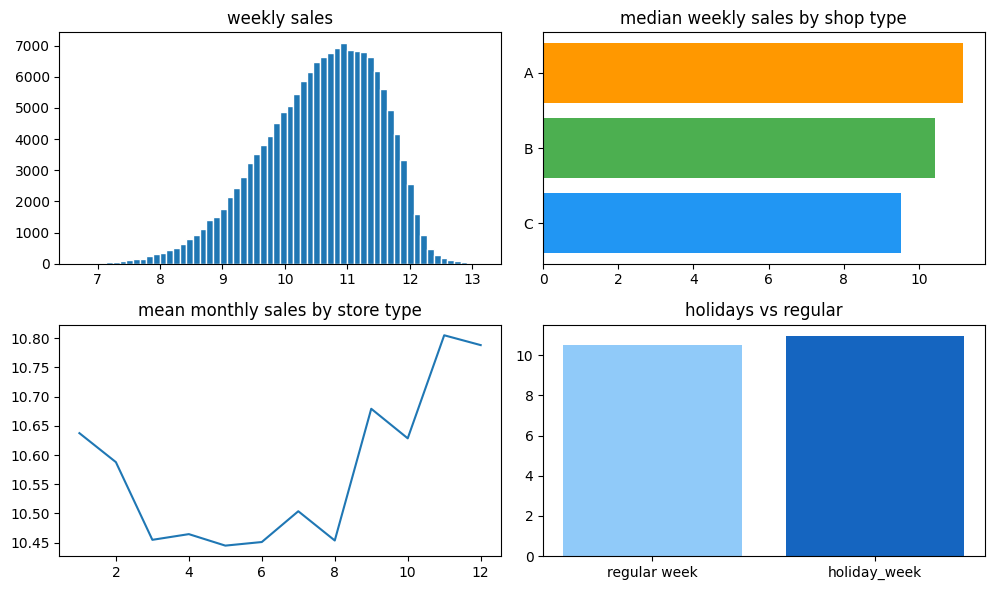

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1
fig, axes = plt.subplots(2, 2, figsize = (10, 6))
axes[0, 0].set_title('weekly sales')
axes[0, 0].hist(df['weekly_sales'], bins = 60, edgecolor = 'white')
# 2
type_sales = df.groupby('store_type')['weekly_sales'].median().sort_values()
axes[0, 1].set_title('median weekly sales by shop type')
axes[0, 1].barh(type_sales.index, type_sales.values, color=['#2196F3','#4CAF50','#FF9800'])
# 3
monthly = df.groupby('month')['weekly_sales'].mean()
axes[1, 0].set_title('mean sales by month')
axes[1, 0].plot(monthly.index, monthly.values)
# 4
holiday_camp = df.groupby('is_holiday')['weekly_sales'].mean()
axes[1, 1].set_title('holidays vs regular')
axes[1, 1].bar(['regular week', 'holiday_week'], holiday_camp.values, color=['#90CAF9','#1565C0'])

plt.tight_layout()

## Heatmap

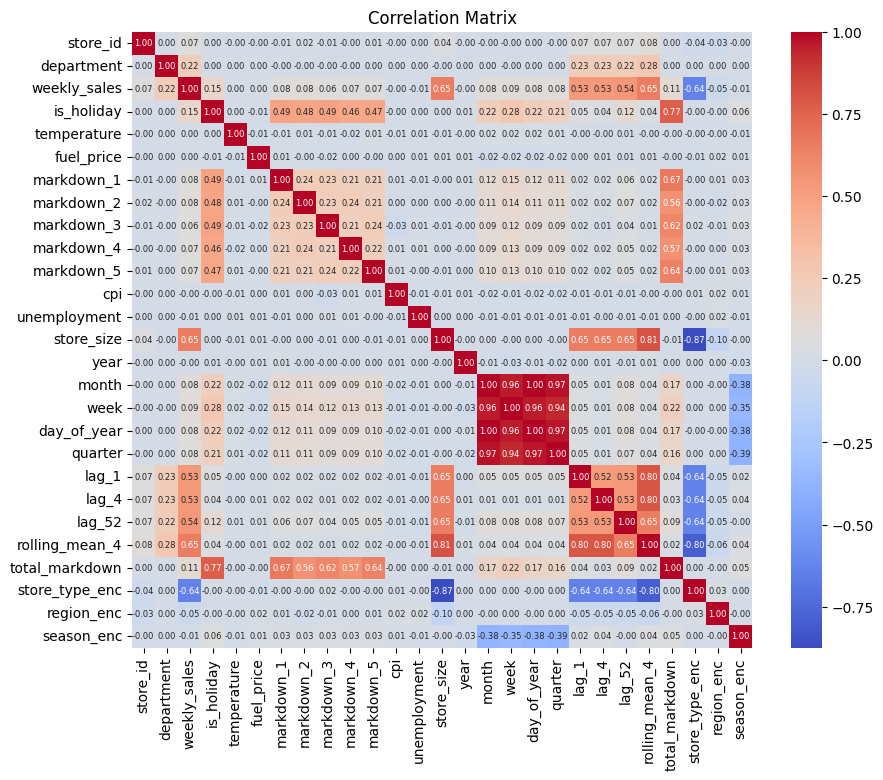

In [12]:
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,      # писать числа
    cmap="coolwarm", # цвета
    fmt=".2f" ,       # 2 знака после точки
    annot_kws={"size": 6}
)

plt.title("Correlation Matrix")

plt.show()

# Ejections

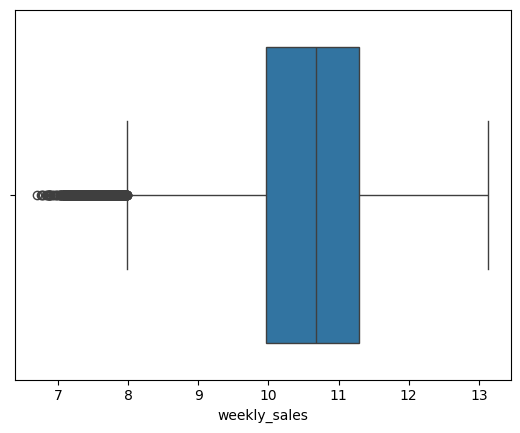

In [13]:
import numpy as np

sns.boxplot(x=df["weekly_sales"])

plt.show()


# Training

## XGBoost

In [14]:
import xgboost


xgb = xgboost.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mape'
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)


[0]	validation_0-mape:0.07548
[50]	validation_0-mape:0.06150
[100]	validation_0-mape:0.05526
[150]	validation_0-mape:0.05265
[200]	validation_0-mape:0.05152
[250]	validation_0-mape:0.05102
[300]	validation_0-mape:0.05079
[350]	validation_0-mape:0.05066
[400]	validation_0-mape:0.05058
[450]	validation_0-mape:0.05053
[500]	validation_0-mape:0.05049
[550]	validation_0-mape:0.05046
[600]	validation_0-mape:0.05044
[642]	validation_0-mape:0.05043


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=20,
             enable_categorical=False, eval_metric='mape', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [15]:
xgb.score(X_train, y_train), xgb.score(X_test, y_test) # overfitting check

(0.5573666096431651, 0.5568704460294447)

## CatBoost

In [16]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


### Without HalvingRandomSearchCV

In [17]:
from catboost import CatBoostRegressor

cbr = CatBoostRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    eval_metric="MAPE",
    random_strength=1,
    bagging_temperature=1,
    bootstrap_type='Bayesian',
    rsm=0.8,
    random_state=42,
    verbose=200,
    early_stopping_rounds=100
)

cbr.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

0:	learn: 0.0726981	test: 0.0748019	best: 0.0748019 (0)	total: 120ms	remaining: 5m 59s
200:	learn: 0.0504565	test: 0.0503768	best: 0.0503747 (195)	total: 14.8s	remaining: 3m 26s
400:	learn: 0.0503051	test: 0.0502958	best: 0.0502938 (376)	total: 25.6s	remaining: 2m 45s
600:	learn: 0.0501589	test: 0.0502851	best: 0.0502830 (592)	total: 32.1s	remaining: 2m 7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.05028297453
bestIteration = 592

Shrink model to first 593 iterations.


CatBoostRegressor(bagging_temperature=1, bootstrap_type='Bayesian', depth=6, early_stopping_rounds=100, eval_metric='MAPE', l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', n_estimators=3000, random_state=42, random_strength=1, rsm=0.8, verbose=200)

### With HalvingRandomSearchCV

In [18]:
from catboost import CatBoostRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

params = {'n_estimators': [500, 1000, 2000],
          'learning_rate': [0.005, 0.01, 0.02],
          'depth': [4, 6, 8],
          'l2_leaf_reg': [1, 3, 5],
          'random_strength': [1],
          'bagging_temperature': [1],
          'bootstrap_type': ['Bayesian'],
          'rsm': [0.8],
          'random_state': [42]
          }

cbr_hs = HalvingRandomSearchCV(estimator=CatBoostRegressor(),
                           param_distributions=params,
                           factor=3,
                           n_jobs=-1,
                           random_state=42)

cbr_hs.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 81 is smaller than n_iter=14000. Running 81 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


0:	learn: 0.0734058	test: 0.0755241	best: 0.0755241 (0)	total: 56.2ms	remaining: 56.2s
200:	learn: 0.0513164	test: 0.0520443	best: 0.0520443 (200)	total: 5.91s	remaining: 23.5s
400:	learn: 0.0505356	test: 0.0505553	best: 0.0505553 (400)	total: 11.7s	remaining: 17.5s
600:	learn: 0.0504524	test: 0.0503696	best: 0.0503695 (595)	total: 17.9s	remaining: 11.9s
800:	learn: 0.0503994	test: 0.0503183	best: 0.0503181 (790)	total: 23.4s	remaining: 5.82s
999:	learn: 0.0503504	test: 0.0503010	best: 0.0503000 (956)	total: 29.9s	remaining: 0us

bestTest = 0.05029999656
bestIteration = 956

Shrink model to first 957 iterations.


HalvingRandomSearchCV(estimator=CatBoostRegressor(loss_function='RMSE'),
                      n_jobs=-1,
                      param_distributions={'bagging_temperature': [1],
                                           'bootstrap_type': ['Bayesian'],
                                           'depth': [4, 6, 8],
                                           'early_stopping_rounds': [100],
                                           'eval_metric': ['MAPE'],
                                           'l2_leaf_reg': [1, 3, 5],
                                           'learning_rate': [0.005, 0.01, 0.02],
                                           'n_estimators': [500, 1000, 2000],
                                           'random_state': [42],
                                           'random_strength': [1], 'rsm': [0.8],
                                           'verbose': [200]},
                      random_state=42)

In [19]:
cbr_hs.score(X_test, y_test)

np.float64(0.5579511215172812)

In [27]:
cbr_hs.best_params_

{'verbose': 200,
 'rsm': 0.8,
 'random_strength': 1,
 'random_state': 42,
 'n_estimators': 1000,
 'learning_rate': 0.01,
 'l2_leaf_reg': 5,
 'eval_metric': 'MAPE',
 'early_stopping_rounds': 100,
 'depth': 6,
 'bootstrap_type': 'Bayesian',
 'bagging_temperature': 1}

## With LightGBM

In [20]:
import lightgbm

lgbm = lightgbm.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lightgbm.early_stopping(50),
        lightgbm.log_evaluation(100)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036242 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3903
[LightGBM] [Info] Number of data points in the train set: 140000, number of used features: 26
[LightGBM] [Info] Start training from score 10.557400
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.498806
[200]	valid_0's l2: 0.426057
[300]	valid_0's l2: 0.410982
[400]	valid_0's l2: 0.407716
[500]	valid_0's l2: 0.406954
[600]	valid_0's l2: 0.406764
Early stopping, best iteration is:
[574]	valid_0's l2: 0.406733


LGBMRegressor(learning_rate=0.01, max_depth=6, n_estimators=1000, n_jobs=-1,
              random_state=42)

# Evaluation



In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, PredictionErrorDisplay
from sklearn.model_selection import cross_val_score

def evaluation(X_test, y_test, model):

  y_preds = model.predict(X_test)

  y_test_orig = np.expm1(y_test)

  y_preds_orig = np.expm1(y_preds)


  r2  = model.score(X_test, y_test)
  mae  = mean_absolute_error(y_test_orig, y_preds_orig)
  rmse = np.sqrt(mean_squared_error(y_test_orig, y_preds_orig))
  mape = (abs(y_test_orig - y_preds_orig) / y_test_orig).mean() * 100

  return {
      'r2': r2,
      'mae': mae,
      'rmse': rmse,
      'mape': mape
    }

## XGBoost

In [22]:
evaluation(X_test=X_test, y_test=y_test, model=xgb)

{'r2': 0.5568704460294447,
 'mae': 30940.92819464356,
 'rmse': np.float64(44103.63576255939),
 'mape': np.float64(66.21119496289614)}

## CatBoost

In [23]:
evaluation(X_test=X_test, y_test=y_test, model=cbr) # without HalvingRandomSearchCV

{'r2': np.float64(0.5581115975109774),
 'mae': 30801.142375340023,
 'rmse': np.float64(43599.70945728244),
 'mape': np.float64(66.83635130633047)}

In [24]:
evaluation(X_test=X_test, y_test=y_test, model=cbr_hs) # with HalvingRandomSearchCV

{'r2': np.float64(0.5579511215172812),
 'mae': 30830.895437604853,
 'rmse': np.float64(43711.20370303589),
 'mape': np.float64(66.75729971360809)}

## LightGBM

In [25]:
evaluation(X_test=X_test, y_test=y_test, model=lgbm)

{'r2': 0.5560531491841598,
 'mae': 30928.56668406551,
 'rmse': np.float64(44060.10468816214),
 'mape': np.float64(66.52074863407012)}

# Save all models

In [29]:
import joblib

joblib.dump(cbr, 'cbr.pkl')
joblib.dump(cbr_hs, 'cbr_hs.pkl')
joblib.dump(lgbm, 'lgbm.pkl')
joblib.dump(xgb, 'xgb.pkl')

['xgb.pkl']